In [1]:
 
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# =========================
# CONFIGURACIÓN
# =========================
FILE_PATH = "../../../data/processed/DCABPs/topics_probs.xlsx"
 
ID_COL    = "id"
EVENT_COL = "PD_event"          # 1=PD, 0=censura/no PD observado
TIME_COL  = "Obs_time"  # días hasta PD o censura (OJO: tiene espacio final en tu fichero)
 
# Definición de hipertópico desfavorable (ajústalo si queréis probar 3+5 en vez de 3+4+5)
UNF_TOPICS = [3, 4, 5]  # pUF = p3+p4+p5
 
# Longitud del "mes" para mapear mes->días (en tu Excel es mensual, así que 30 suele ser razonable)
DAYS_PER_MONTH = 30.0
 
# Lookback (AUC rolling) y horizontes de predicción
LOOKBACK_MONTHS_LIST = [3, 4]   # AUC últimos 3 o 4 meses
HORIZON_MONTHS_LIST  = [3, 4]   # predecir PD en próximos 3 o 4 meses
 
# Umbrales candidatos: se generan por cuantiles del predictor (robusto)
N_QUANTILES = 25
 
# Guardar figuras/tablas
SAVE_PREFIX = "alarm_auc_rolling"
 


In [2]:
 
# =========================
# 1) CARGA Y DETECCIÓN DE COLUMNAS DE PROBABILIDADES
# =========================
df = pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx')
probs_df = pd.read_excel(FILE_PATH)
df=df.merge(probs_df, left_on='S_RECORD_id', right_on='id')

# Detectar columnas tipo mesX_topicY
prob_cols = [c for c in df.columns if re.match(r"mes\d+_topic[0-5]$", str(c))]
if len(prob_cols) == 0:
    raise ValueError("No encuentro columnas tipo 'mesX_topicY'. Revisa nombres de columnas.")
 
# Meses disponibles
months = sorted(set(int(re.findall(r"mes(\d+)_", c)[0]) for c in prob_cols))
max_month = max(months)
 
print(f"N pacientes: {df.shape[0]}")
print(f"Meses detectados: 1..{max_month} (total {len(months)})")
print(f"Columnas de probabilidad detectadas: {len(prob_cols)} (= {len(months)} meses × 6 topics)")
 


N pacientes: 178
Meses detectados: 1..32 (total 32)
Columnas de probabilidad detectadas: 192 (= 32 meses × 6 topics)


In [3]:
import re, math

COHORT_COL = "Cohort"

MONTH_LEN_DAYS = 30
 
# Define unfavorable topics (your main definition)
BAD_TOPICS = [3, 4, 5]
 
# Use your chosen operating point (example: W=3, H=4, theta=1.6110)
W   = 3
H   = 4
THR = 1.6110
 
# Detect available months from column names mes{m}_topic{t}
month_nums = sorted({
    int(m.group(1))
    for c in df.columns
    for m in [re.match(r"mes(\d+)_topic[0-5]$", str(c))]
    if m
})
 

In [4]:
def compute_puf_table(df, bad_topics=BAD_TOPICS):
    """Return pUF per month as a dataframe with columns = month ints."""
    out = {}
    for m in month_nums:
        cols = [f"mes{m}_topic{t}" for t in bad_topics]
        if all(c in df.columns for c in cols):
            # if any is NaN -> NaN (so we don't pretend the sum exists)
            out[m] = df[cols].sum(axis=1, skipna=False)
    return pd.DataFrame(out)
 
puf = compute_puf_table(df)
 
def build_decision_points(df, puf, W, H, month_len_days=MONTH_LEN_DAYS):
    """
    One row per patient-month decision point (end of month m).
    Feature: rolling AUC_W(m) = sum_{m-W+1..m} pUF
    Label y=1 if PD occurs within next H months, else 0
    Excludes decision points without enough past data or insufficient follow-up.
    """
    rows = []
    for i in range(len(df)):
        pid = df.loc[i, ID_COL]
        ev  = df.loc[i, EVENT_COL]
        t   = df.loc[i, TIME_COL]
 
        if pd.isna(ev) or pd.isna(t):
            continue
        ev = int(ev)
        t  = float(t)
 
        # maximum usable month: limited by pUF availability and follow-up duration
        puf_row = puf.iloc[i]
        last_valid_month = puf_row.last_valid_index()
        if last_valid_month is None:
            continue
        max_m = int(last_valid_month)
        max_m = min(max_m, int(math.floor(t / month_len_days)))
 
        for m in range(W, max_m + 1):
            end_day = m * month_len_days
            window = puf_row.loc[m - W + 1 : m]
            if window.isna().any():
                continue
            auc = float(window.sum())
 
            if ev == 1:
                # must be before PD
                if t <= end_day:
                    continue
                y = 1 if (t <= end_day + H * month_len_days) else 0
                rows.append((pid, m, end_day, auc, y, ev, t))
            else:
                # ev == 0 (censored): must have enough follow-up to certify "no PD within horizon"
                if t < end_day + H * month_len_days:
                    continue
                rows.append((pid, m, end_day, auc, 0, ev, t))
 
    return pd.DataFrame(rows, columns=["id","month","day","auc","y","event","t_days"])
 


In [5]:
dp = build_decision_points(df, puf, W=W, H=H)
dp["alarm"] = dp["auc"] >= THR
dp["TP"] = (dp["alarm"] & (dp["y"] == 1))
 


In [6]:
# Encuentra 3 pacientes
 
def patient_month_series(df, puf, pid, W=W, month_len_days=MONTH_LEN_DAYS):
    row = df[df[ID_COL] == pid].iloc[0]
    ev  = int(row[EVENT_COL])
    t   = float(row[TIME_COL])
 
    i = df.index[df[ID_COL] == pid][0]
    puf_row = puf.iloc[i]
 
    last_valid_month = puf_row.last_valid_index()
    if last_valid_month is None:
        return None
 
    max_m = int(last_valid_month)
    max_m = min(max_m, int(math.floor(t / month_len_days)))
    months = np.arange(1, max_m + 1)
 
    pvals = puf_row.loc[months].astype(float).values
    auc = np.full_like(pvals, np.nan, dtype=float)
    for idx, m in enumerate(months):
        if m >= W:
            w = puf_row.loc[m-W+1:m]
            if not w.isna().any():
                auc[idx] = float(w.sum())
 
    return pd.DataFrame({"month": months, "pUF": pvals, "AUC": auc})
 
def remind_window(pid, alarm_month, ev, t_days, max_month, pad=4):
    if alarm_month is None or pd.isna(alarm_month):
        start, end = 1, max_month
    else:
        start = max(1, int(alarm_month) - pad)
        end   = min(max_month, int(alarm_month) + pad)
 
    if ev == 1:
        ev_month = int(math.ceil(t_days / MONTH_LEN_DAYS))
        start = min(start, max(1, ev_month - pad))
        end   = max(end, min(max_month, ev_month + pad))
 
    return start, end
 


In [7]:
# Per-patient summary
auc_at_W = dp[dp["month"] == W].set_index("id")["auc"]
alarm_prop = dp.groupby("id")["alarm"].mean()
first_alarm = dp[dp["alarm"]].groupby("id")["month"].min()
first_tp_alarm = dp[dp["TP"]].groupby("id")["month"].min()
 
base = df.set_index(ID_COL)[[COHORT_COL, EVENT_COL, TIME_COL]].copy()
summ = base.join(auc_at_W.rename("AUC_mW")).join(alarm_prop.rename("alarm_prop"))
summ = summ.join(first_alarm.rename("first_alarm_m")).join(first_tp_alarm.rename("first_TP_alarm_m"))
 
# Lead time (months) from first TP alarm to PD
summ["lead_months_first_TP"] = (summ[TIME_COL] - summ["first_TP_alarm_m"] * MONTH_LEN_DAYS) / MONTH_LEN_DAYS
 
# Candidate pools
deter_pool = summ[
    (summ[EVENT_COL] == 1) &
    (summ["first_TP_alarm_m"].notna()) &
    (summ["AUC_mW"] < THR) &
    (summ["alarm_prop"] < 0.9)
].copy()
 
persist_pool = summ[
    (summ[EVENT_COL] == 1) &
    (summ["first_TP_alarm_m"].notna()) &
    (summ["AUC_mW"] >= THR) &
    (summ["alarm_prop"] >= 0.8)
].copy()
 
false_pool = summ[
    (summ[EVENT_COL] == 0) &
    (summ["first_alarm_m"].notna())
].copy()
false_pool["followup_months"] = np.floor(false_pool[TIME_COL] / MONTH_LEN_DAYS).astype(int)
 
# Pick "clean" exemplars
deter_id   = deter_pool.sort_values("lead_months_first_TP", ascending=False).index[0] if len(deter_pool) else None
persist_id = persist_pool.sort_values("alarm_prop", ascending=False).index[0] if len(persist_pool) else None
false_id   = false_pool.sort_values(["alarm_prop","followup_months"], ascending=[True,False]).index[0] if len(false_pool) else None
 
picked = {"deteriorating": deter_id, "persistent_unfavourable": persist_id, "false_alarm": false_id}
picked
 


{'deteriorating': 81004,
 'persistent_unfavourable': 63001,
 'false_alarm': 31001}

In [8]:
# Falta 1 paciente CODIGO PARA PLOTEO CORRECTO DE 3 PACIENTES
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
MONTH_LEN_DAYS = 30.0  # como lo estabas usando
 
def plot_patient(pid, start_m=None, end_m=None, normalize_auc=True):
    s = patient_month_series(df, puf, pid, W=W)   # debe devolver columnas: month, pUF, AUC
    row = df.loc[df[ID_COL] == pid].iloc[0]
    ev  = int(row[EVENT_COL])
    t   = float(row[TIME_COL])
    cohort = row[COHORT_COL]
 
    if start_m is None: start_m = int(s["month"].min())
    if end_m is None:   end_m   = int(s["month"].max())
 
    ss = s[(s["month"] >= start_m) & (s["month"] <= end_m)].copy()
 
    # Valores de alarma (si existen en summ)
    fa = summ.loc[pid, "first_alarm_m"] if pid in summ.index else np.nan
    fta = summ.loc[pid, "first_TP_alarm_m"] if pid in summ.index else np.nan
 
    fig, ax = plt.subplots(figsize=(9, 4))
 
    ax.plot(ss["month"], ss["pUF"], marker="o", label="pUF (unfavourable hypertopic)")
 
    if normalize_auc:
        ax.plot(ss["month"], ss["AUC"]/W, marker="o", label=f"Rolling AUC/W (W={W})")
        ax.axhline(THR/W, linestyle="--", label=f"Threshold θ={THR:.2f} (scaled θ/W={THR/W:.2f})")
        ax.set_ylabel("Probability / normalized AUC")
    else:
        ax2 = ax.twinx()
        ax2.plot(ss["month"], ss["AUC"], marker="o", label=f"Rolling AUC (W={W})")
        ax2.axhline(THR, linestyle="--")
        ax.set_ylabel("pUF")
        ax2.set_ylabel("Rolling AUC")
 
    # Marcas verticales
    if pd.notna(fa) and (start_m <= fa <= end_m):
        ax.axvline(int(fa), linestyle="--", label=f"First alarm (m={int(fa)})")
 
    if pd.notna(fta) and (start_m <= fta <= end_m):
        ax.axvline(int(fta), linestyle=":", label=f"First TP alarm (m={int(fta)})")
 
    if ev == 1:
        ax.axvline(t / MONTH_LEN_DAYS, linestyle="-.", label=f"PD at day {t:.0f}", c='r')
    plt.ylim([0,1])
    ax.set_title(f"Patient {pid} ({cohort}) — rolling-AUC alarm (H={H} months)")
    ax.set_xlabel("Month")
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    #plt.savefig(f"{pid}.svg")
    plt.show()


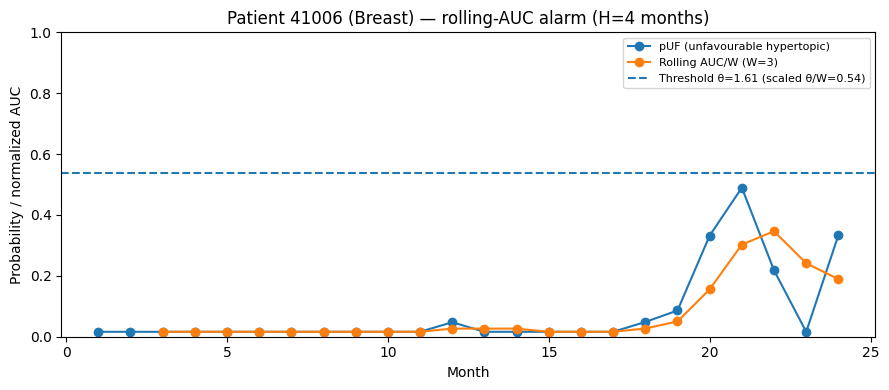

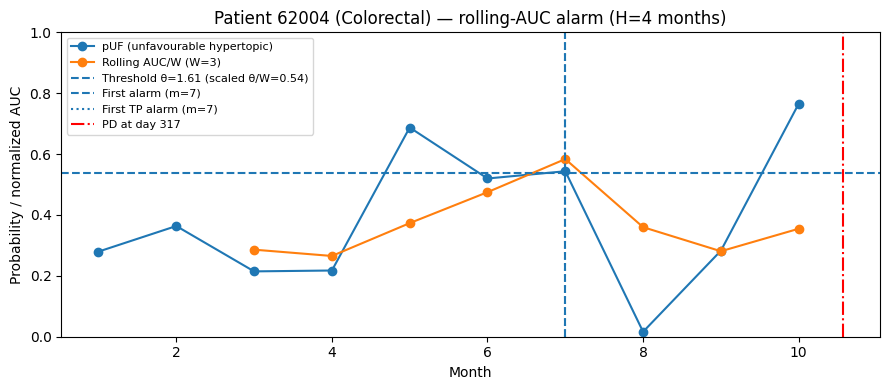

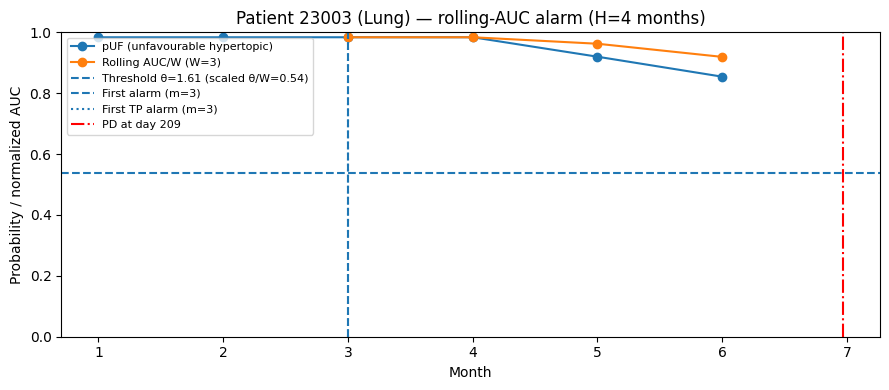

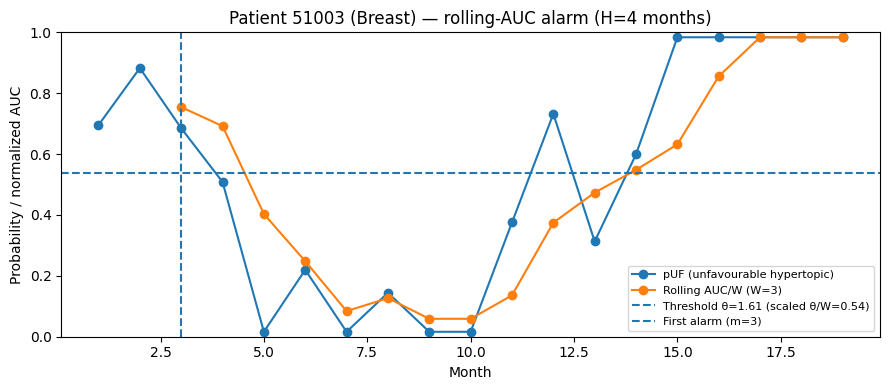

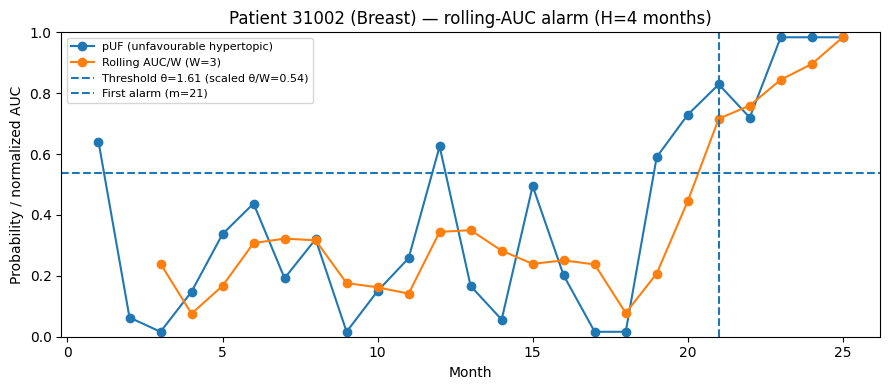

In [9]:
 
# Llamadas (sin comentar)
for pid in [41006,62004, 23003, 51003,31002]:
    #info = describe_pick(pid)  # si la tienes; si no, pon start/end manual
    #plot_patient(pid, start_m=info["plot_window_months"][0], end_m=info["plot_window_months"][1])
    plot_patient(pid)